## Exploratory Data Analysis (EDA)

Visual exploration of the cleaned data across the 5 SQL-independent business 
questions (Q1–Q5), before moving to Phase 3 (SQL). Q6 (RFM) is intentionally 
excluded here — that calculation and segmentation is SQL-led, using window 
functions in Phase 3.

Loading cleaned CSVs — only the 7 tables needed for these 5 charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv('../data/cleaned/orders_cleaned.csv')
customers = pd.read_csv('../data/cleaned/customers_cleaned.csv')
products = pd.read_csv('../data/cleaned/products_cleaned.csv')
order_items = pd.read_csv('../data/cleaned/order_items_cleaned.csv')
order_payments = pd.read_csv('../data/cleaned/order_payments_cleaned.csv')
category_translation = pd.read_csv('../data/cleaned/category_translation_cleaned.csv')
sellers = pd.read_csv('../data/cleaned/sellers_cleaned.csv')

### Chart 1: Revenue by Category

Revenue (`price`) lives in `order_items`, category names live in `products`, 
and English category names live in `category_translation` — three separate 
tables. We merge them together first, then group by category and sum 
revenue, to find which categories drive the most sales.

In [3]:
merged = order_items.merge(products, on='product_id', how='left')
merged = merged.merge(category_translation, on='product_category_name', how='left')

In [4]:
merged.shape

(112650, 16)

In [5]:
category_revenue = merged.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)
category_revenue.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

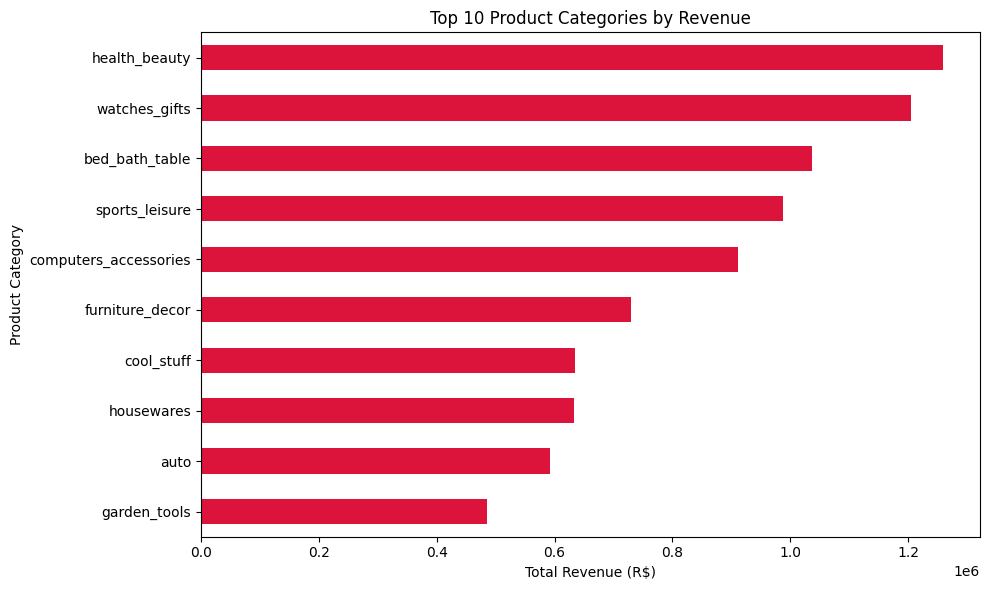

In [6]:
plt.figure(figsize=(10, 6))
category_revenue.head(10).plot(kind='barh', color='crimson')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Product Category')
plt.title('Top 10 Product Categories by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Chart 2: Order Count Distribution per Customer

Using `customer_unique_id` (not `customer_id`) to correctly identify the 
same real-world person across multiple orders. This visualizes what we 
predicted in Phase 1 — that the vast majority of Olist customers are 
one-time buyers.

In [7]:
orders_with_customers = orders.merge(customers, on='customer_id', how='left')

order_counts = orders_with_customers.groupby('customer_unique_id')['order_id'].count()

order_counts.value_counts().sort_index()

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

**Finding:** Out of ~96,096 unique customers (`customer_unique_id`), 93,099 
(≈96.9%) placed exactly one order — confirming the ~97% one-time-buyer rate 
assumed back in Phase 1. Repeat customers drop off sharply: only 2,745 
ordered twice, and fewer than 50 customers ordered more than 4 times. This 
is the concrete evidence behind our decision to scope out churn/retention 
analysis and instead frame Q2 as one-time vs. repeat buyer revenue 
contribution.

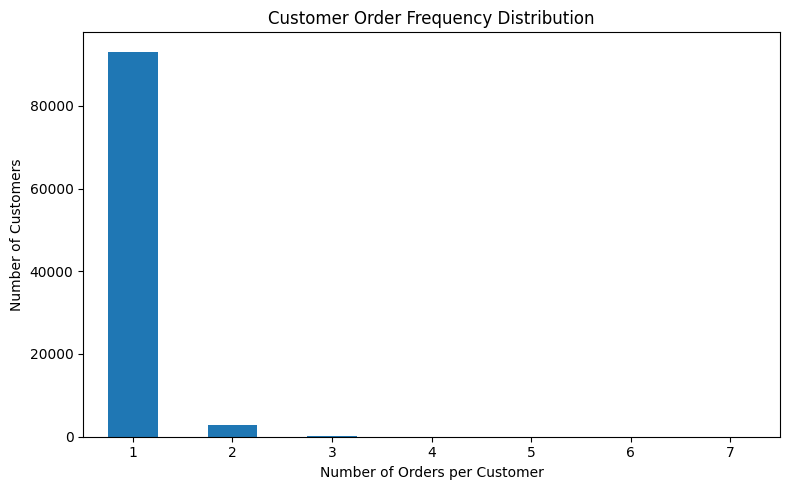

In [8]:
plt.figure(figsize=(8, 5))
order_counts.value_counts().sort_index().head(7).plot(kind='bar')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')
plt.title('Customer Order Frequency Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

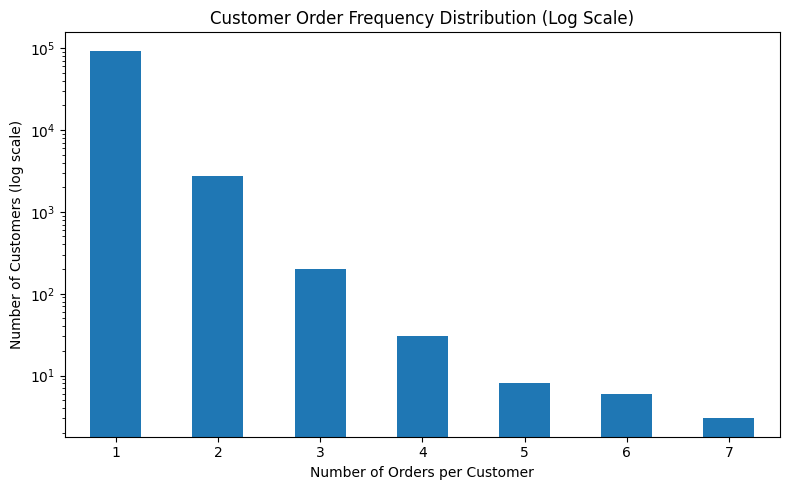

In [9]:
plt.figure(figsize=(8, 5))
order_counts.value_counts().sort_index().head(7).plot(kind='bar')
plt.yscale('log')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers (log scale)')
plt.title('Customer Order Frequency Distribution (Log Scale)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Chart 3: Delivery Delay Distribution

Visualizing the spread of `delivery_delay_days` (actual delivery date minus 
estimated date) across all delivered orders. We already know the split is 
~92% early, ~1% on-time, ~7% late — this histogram shows the actual shape 
of that distribution, including how early or how late orders tend to be, 
not just the three-way split.

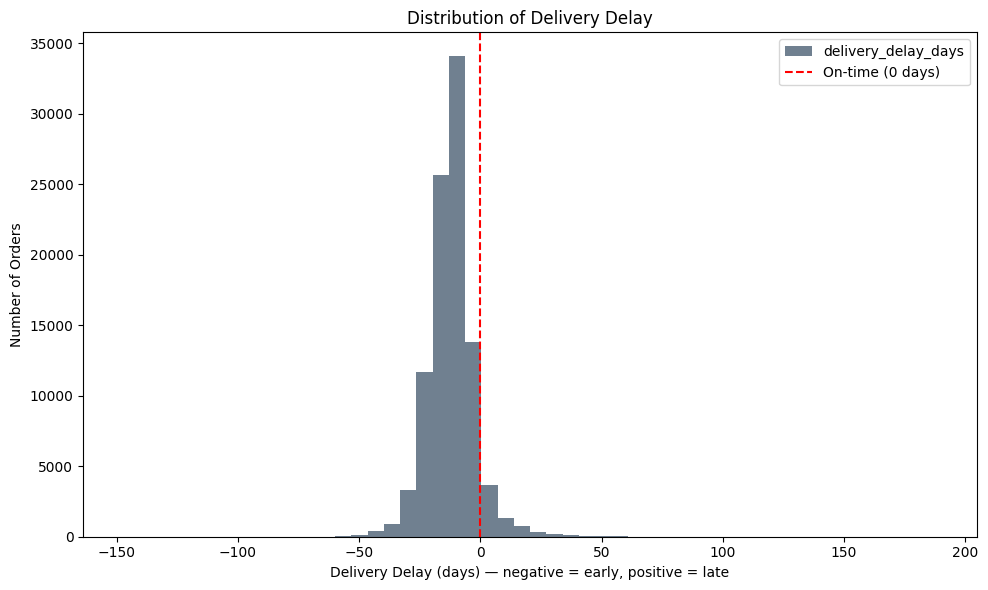

In [10]:
plt.figure(figsize=(10, 6))
orders['delivery_delay_days'].dropna().plot(kind='hist', bins=50, color='slategrey')
plt.axvline(x=0, color='red', linestyle='--', label='On-time (0 days)')
plt.xlabel('Delivery Delay (days) — negative = early, positive = late')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delivery Delay')
plt.legend()
plt.tight_layout()
plt.show()

### Chart 4: Payment Type Breakdown

Visualizing which payment methods customers use most often, and how much 
each type is worth in total transaction value — feeds directly into Q4 
(Payment Behavior).

In [11]:
payment_counts = order_payments['payment_type'].value_counts()
payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

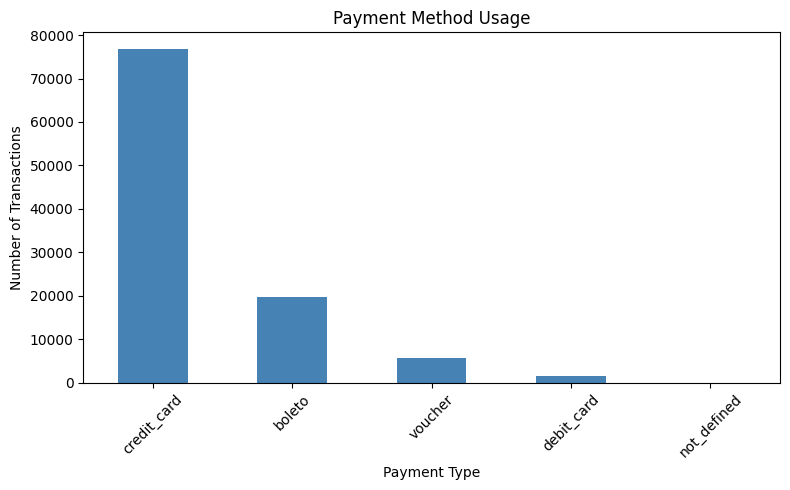

In [12]:
plt.figure(figsize=(8, 5))
payment_counts.plot(kind='bar', color='steelblue')
plt.xlabel('Payment Type')
plt.ylabel('Number of Transactions')
plt.title('Payment Method Usage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** Credit card dominates as the primary payment method (~74% of 
transactions), with boleto — a Brazil-specific bank-slip payment method — 
as a distant second (~19%). Voucher and debit card together make up a small 
remainder, and `not_defined` (3 transactions) is a negligible data artifact.

### Average Order Value by Payment Type

Payment count alone doesn't reveal spending behavior — this checks whether 
customers using certain payment methods (e.g., credit card with 
installments) tend to spend more per transaction than others.

In [13]:
avg_payment_value = order_payments.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)
avg_payment_value

payment_type
credit_card    163.319021
boleto         145.034435
debit_card     142.570170
voucher         65.703354
not_defined      0.000000
Name: payment_value, dtype: float64

**Finding:** Credit card leads not just in transaction count but also in 
average value (R$163.32) — the highest of all payment types — making it 
the dominant revenue driver by both volume and value. Voucher transactions 
have the lowest average value (R$65.70), consistent with vouchers typically 
being used for smaller or discount-driven purchases. The 3 `not_defined` 
transactions show R$0 average value, suggesting these are likely failed or 
cancelled transactions rather than a genuine data gap.

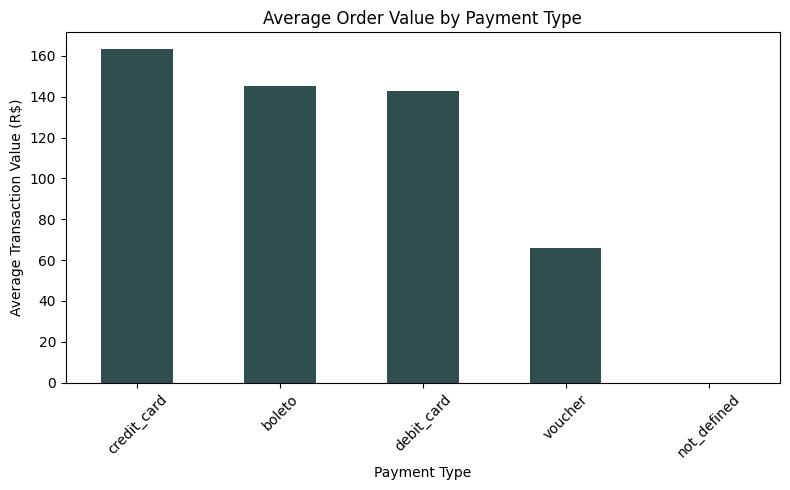

In [14]:
plt.figure(figsize=(8, 5))
avg_payment_value.plot(kind='bar', color='darkslategray')
plt.xlabel('Payment Type')
plt.ylabel('Average Transaction Value (R$)')
plt.title('Average Order Value by Payment Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart 5: Seller Revenue Concentration

Checking whether a small number of sellers account for a disproportionate 
share of total revenue — a common "marketplace concentration" pattern. 
Feeds Q5 (Seller Performance & Marketplace Health).

In [15]:
seller_revenue = order_items.groupby('seller_id')['price'].sum().sort_values(ascending=False)
seller_revenue.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

### Seller Concentration — Top 10% Revenue Share

Checking what percentage of total revenue comes from just the top 10% of 
sellers (by revenue) — this is the actual test of marketplace concentration, 
not just identifying the top individual sellers.

In [16]:
total_sellers = len(seller_revenue)
top_10_percent_count = int(total_sellers * 0.10)

top_10_percent_revenue = seller_revenue.head(top_10_percent_count).sum()
total_revenue_all_sellers = seller_revenue.sum()

percentage = (top_10_percent_revenue / total_revenue_all_sellers) * 100

print(f"Total sellers: {total_sellers}")
print(f"Top 10% of sellers: {top_10_percent_count} sellers")
print(f"Revenue from top 10%: R$ {top_10_percent_revenue:,.2f}")
print(f"Total revenue (all sellers): R$ {total_revenue_all_sellers:,.2f}")
print(f"Percentage of revenue from top 10% of sellers: {percentage:.2f}%")

Total sellers: 3095
Top 10% of sellers: 309 sellers
Revenue from top 10%: R$ 9,173,621.14
Total revenue (all sellers): R$ 13,591,643.70
Percentage of revenue from top 10% of sellers: 67.49%


**Finding:** The top 10% of sellers (309 out of 3,095) generate 67.49% of 
total marketplace revenue (R$9,173,621 of R$13,591,644), while the remaining 
90% of sellers split just 32.5% between them. This is a significant 
concentration pattern — Olist's revenue is heavily dependent on a relatively 
small group of top-performing sellers, which represents a real business 
risk if any of these key sellers were to leave the platform.

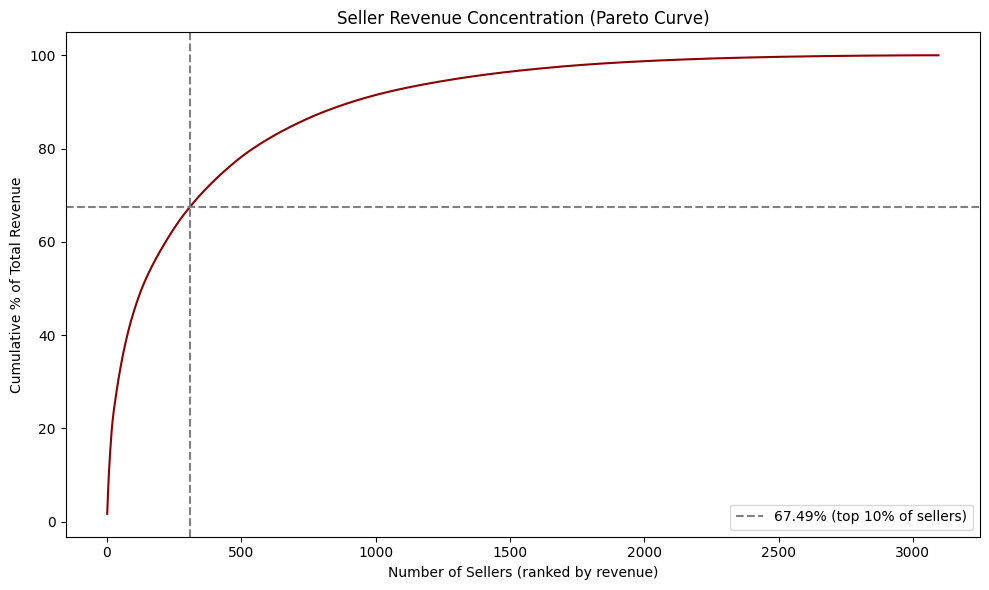

In [17]:
cumulative_pct = (seller_revenue.cumsum() / seller_revenue.sum()) * 100

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_pct) + 1), cumulative_pct.values, color='darkred')
plt.axhline(y=67.49, color='gray', linestyle='--', label='67.49% (top 10% of sellers)')
plt.axvline(x=309, color='gray', linestyle='--')
plt.xlabel('Number of Sellers (ranked by revenue)')
plt.ylabel('Cumulative % of Total Revenue')
plt.title('Seller Revenue Concentration (Pareto Curve)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
orders_check = pd.read_csv('../data/cleaned/orders_cleaned.csv')
orders_check.to_csv('../data/cleaned/orders_cleaned.csv', index=False, na_rep='')